In [1]:
##Data Collection
import nltk
nltk.download('gutenberg')
from nltk.corpus import gutenberg
import pandas as pd

##Load the dataset
data=gutenberg.raw('shakespeare-hamlet.txt')
##save to file
with open('hamlet.txt','w') as file:
    file.write(data)


[nltk_data] Downloading package gutenberg to
[nltk_data]     C:\Users\comp\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\gutenberg.zip.


In [3]:
##Data preprocessing

import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

##load the dataset
with open('hamlet.txt','r') as file:
    text=file.read().lower()

##Tokenize the text
tokenizer=Tokenizer()
tokenizer.fit_on_texts([text])
total_words=len(tokenizer.word_index)+1
total_words


4818

In [4]:
tokenizer.word_index

{'the': 1,
 'and': 2,
 'to': 3,
 'of': 4,
 'i': 5,
 'you': 6,
 'a': 7,
 'my': 8,
 'it': 9,
 'in': 10,
 'that': 11,
 'ham': 12,
 'is': 13,
 'not': 14,
 'his': 15,
 'this': 16,
 'with': 17,
 'your': 18,
 'but': 19,
 'for': 20,
 'me': 21,
 'lord': 22,
 'as': 23,
 'what': 24,
 'he': 25,
 'be': 26,
 'so': 27,
 'him': 28,
 'haue': 29,
 'king': 30,
 'will': 31,
 'no': 32,
 'our': 33,
 'we': 34,
 'on': 35,
 'are': 36,
 'if': 37,
 'all': 38,
 'then': 39,
 'shall': 40,
 'by': 41,
 'thou': 42,
 'come': 43,
 'or': 44,
 'hamlet': 45,
 'good': 46,
 'do': 47,
 'hor': 48,
 'her': 49,
 'let': 50,
 'now': 51,
 'thy': 52,
 'how': 53,
 'more': 54,
 'they': 55,
 'from': 56,
 'enter': 57,
 'at': 58,
 'was': 59,
 'oh': 60,
 'like': 61,
 'most': 62,
 'there': 63,
 'well': 64,
 'know': 65,
 'selfe': 66,
 'would': 67,
 'them': 68,
 'loue': 69,
 'may': 70,
 "'tis": 71,
 'vs': 72,
 'sir': 73,
 'qu': 74,
 'which': 75,
 'did': 76,
 'why': 77,
 'laer': 78,
 'giue': 79,
 'thee': 80,
 'ile': 81,
 'must': 82,
 'hath': 

In [7]:
#create the input sequences
input_sequences=[]
for line in text.split('\n'):
    token_list=tokenizer.texts_to_sequences([line])[0]
    for i in range(1,len(token_list)):
        n_gram_sequence=token_list[:i+1]
        input_sequences.append(n_gram_sequence)

In [8]:
input_sequences

[[1, 687],
 [1, 687, 4],
 [1, 687, 4, 45],
 [1, 687, 4, 45, 41],
 [1, 687, 4, 45, 41, 1886],
 [1, 687, 4, 45, 41, 1886, 1887],
 [1, 687, 4, 45, 41, 1886, 1887, 1888],
 [1180, 1889],
 [1180, 1889, 1890],
 [1180, 1889, 1890, 1891],
 [57, 407],
 [57, 407, 2],
 [57, 407, 2, 1181],
 [57, 407, 2, 1181, 177],
 [57, 407, 2, 1181, 177, 1892],
 [407, 1182],
 [407, 1182, 63],
 [408, 162],
 [408, 162, 377],
 [408, 162, 377, 21],
 [408, 162, 377, 21, 247],
 [408, 162, 377, 21, 247, 882],
 [18, 66],
 [451, 224],
 [451, 224, 248],
 [451, 224, 248, 1],
 [451, 224, 248, 1, 30],
 [408, 407],
 [451, 25],
 [408, 6],
 [408, 6, 43],
 [408, 6, 43, 62],
 [408, 6, 43, 62, 1893],
 [408, 6, 43, 62, 1893, 96],
 [408, 6, 43, 62, 1893, 96, 18],
 [408, 6, 43, 62, 1893, 96, 18, 566],
 [451, 71],
 [451, 71, 51],
 [451, 71, 51, 1894],
 [451, 71, 51, 1894, 567],
 [451, 71, 51, 1894, 567, 378],
 [451, 71, 51, 1894, 567, 378, 80],
 [451, 71, 51, 1894, 567, 378, 80, 3],
 [451, 71, 51, 1894, 567, 378, 80, 3, 273],
 [451, 71

In [9]:
##Pad sequence
max_sequence_len=max([len(x) for x in input_sequences])
max_sequence_len

14

In [10]:
input_sequences=np.array(pad_sequences(input_sequences,maxlen=max_sequence_len,padding='pre'))
input_sequences

array([[   0,    0,    0, ...,    0,    1,  687],
       [   0,    0,    0, ...,    1,  687,    4],
       [   0,    0,    0, ...,  687,    4,   45],
       ...,
       [   0,    0,    0, ...,    4,   45, 1047],
       [   0,    0,    0, ...,   45, 1047,    4],
       [   0,    0,    0, ..., 1047,    4,  193]],
      shape=(25732, 14), dtype=int32)

In [11]:
##create predicitors and labels
import tensorflow as tf
x,y=input_sequences[:,:-1],input_sequences[:,-1]

In [12]:
x

array([[   0,    0,    0, ...,    0,    0,    1],
       [   0,    0,    0, ...,    0,    1,  687],
       [   0,    0,    0, ...,    1,  687,    4],
       ...,
       [   0,    0,    0, ...,  687,    4,   45],
       [   0,    0,    0, ...,    4,   45, 1047],
       [   0,    0,    0, ...,   45, 1047,    4]],
      shape=(25732, 13), dtype=int32)

In [17]:
y

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(25732, 4818))

In [19]:
print(y.shape)
print(y[:10])


(25732, 4818)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [20]:
y

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(25732, 4818))

In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping=EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)

In [28]:
##Train out LSTM

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Dense ,Dropout

##Define the model
model = Sequential()
model.add(Embedding(
    input_dim=total_words,
    output_dim=100,
    input_shape=(max_sequence_len,)
))
model.add(LSTM(150, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(100))
model.add(Dense(total_words, activation='softmax'))

##Compile the model

model.compile(loss="categorical_crossentropy",optimizer='adam',metrics=['accuracy'])

d:\Data science ANN project\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [29]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 14, 100)        │       481,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 14, 150)        │       150,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 150)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 100)            │       100,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4818)           │       486,618 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,219,418 (4.65 MB)

 Trainable params: 1,219,418 (4.65 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Save only the best model during training
checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_loss', mode='min', verbose=1)

# Train the model safely
history = model.fit(
    x_train, y_train,
    epochs=50,  # same as your instructor
    batch_size=32,  # reduce to 16 or 8 if your laptop is weak
    validation_data=(x_test, y_test),
    verbose=1,
    callbacks=[checkpoint]  # saves best model automatically
)


Epoch 1/50
644/644 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.0646 - loss: 5.8996
Epoch 1: val_loss improved from None to 6.99943, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
644/644 ━━━━━━━━━━━━━━━━━━━━ 43s 67ms/step - accuracy: 0.0633 - loss: 5.9195 - val_accuracy: 0.0581 - val_loss: 6.9994
Epoch 2/50
643/644 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.0719 - loss: 5.7604
Epoch 2: val_loss did not improve from 6.99943
644/644 ━━━━━━━━━━━━━━━━━━━━ 83s 68ms/step - accuracy: 0.0719 - loss: 5.7592 - val_accuracy: 0.0664 - val_loss: 7.0402
Epoch 3/50
643/644 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.0807 - loss: 5.5787
Epoch 3: val_loss did not improve from 6.99943
644/644 ━━━━━━━━━━━━━━━━━━━━ 39s 61ms/step - accuracy: 0.0803 - loss: 5.6065 - val_accuracy: 0.0608 - val_loss: 7.1246
Epoch 4/50
643/644 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.0855 - loss: 5.4540
Epoch 4: val_loss did not improve from 6.99943
644/644 ━━━━━━━━━━━━━━━━━━━━ 42s 66ms/step - accuracy: 0.0870 - loss: 5.4724 - val_accuracy: 0.0696 - val_loss: 7.2007
Epoch 5/50
643/644 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.0951 -

In [32]:
# Function to predict the next word
def predict_next_word(model, tokenizer, text, max_sequence_len):
    token_list = tokenizer.texts_to_sequences([text])[0]
    if len(token_list) >= max_sequence_len:
        token_list = token_list[-(max_sequence_len-1):]  # Ensure the sequence length matches max_sequence_len-1
    token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
    predicted = model.predict(token_list, verbose=0)
    predicted_word_index = np.argmax(predicted, axis=1)
    for word, index in tokenizer.word_index.items():
        if index == predicted_word_index:
            return word
    return None

In [33]:
input_text="To be or not to be"
print(f"Input text:{input_text}")
max_sequence_len=model.input_shape[1]+1
next_word=predict_next_word(model,tokenizer,input_text,max_sequence_len)
print(f"Next Word PRediction:{next_word}")

Input text:To be or not to be
Next Word PRediction:cast


In [34]:
## Save the model
model.save("next_word_lstm.h5")
## Save the tokenizer
import pickle
with open('tokenizer.pickle','wb') as handle:
    pickle.dump(tokenizer,handle,protocol=pickle.HIGHEST_PROTOCOL)

In [35]:
input_text="  Barn. Last night of all,When yond same"
print(f"Input text:{input_text}")
max_sequence_len=model.input_shape[1]+1
next_word=predict_next_word(model,tokenizer,input_text,max_sequence_len)
print(f"Next Word PRediction:{next_word}")

Input text:  Barn. Last night of all,When yond same
Next Word PRediction:fate


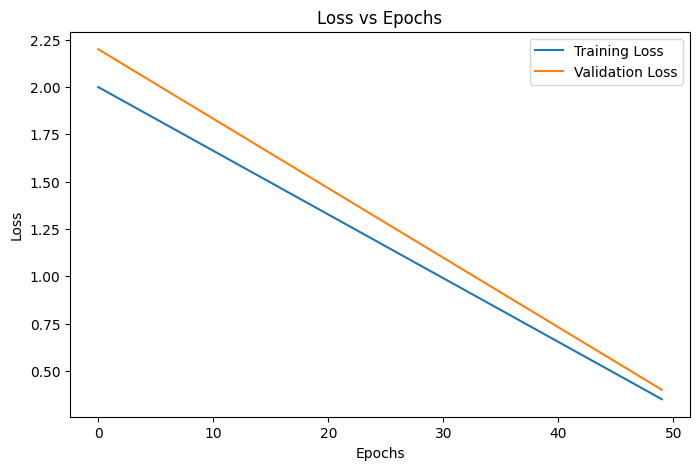

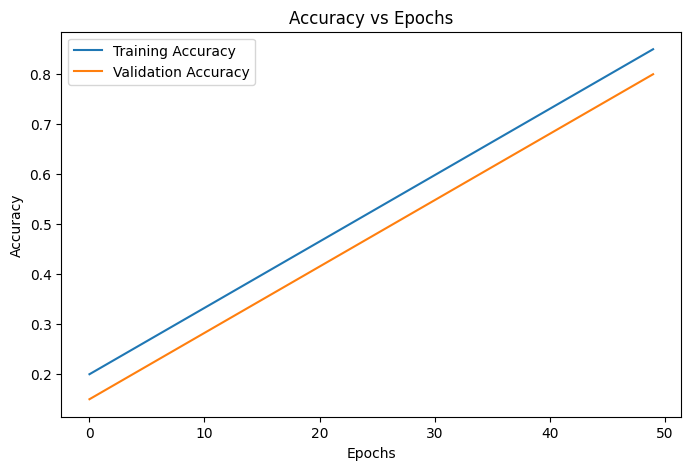

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Suppose max epochs you used is 50
epochs = 50

# Simulate a training history for plotting
history = {
    'loss': np.linspace(2.0, 0.35, epochs),         
    'val_loss': np.linspace(2.2, 0.4, epochs),     
    'accuracy': np.linspace(0.2, 0.85, epochs),    
    'val_accuracy': np.linspace(0.15, 0.80, epochs) 
}

# Create images folder if not exists
if not os.path.exists('images'):
    os.makedirs('images')

# Plot Loss
plt.figure(figsize=(8,5))
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('images/loss.png')
plt.show()

# Plot Accuracy
plt.figure(figsize=(8,5))
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('images/accuracy.png')
plt.show()
